In [50]:
import sys
from packaging.version import Version
import sklearn
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np

from zlib import crc32
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer

In [2]:
import shutil
shutil.rmtree("datasets", ignore_errors=True)

In [17]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    csv_path = Path("datasets/housing/housing.csv")

    if not csv_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

    if not csv_path.is_file():
        found = list(Path("datasets").rglob("*"))
        raise FileNotFoundError(
            f"Extraction did not produce {csv_path}. Found instead: {found}"
        )

    return pd.read_csv(csv_path)

housing_full = load_housing_data()

In [18]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The info() method is useful to get a quick description of the data, in particular the
total number of rows, each attribute’s type, and the number of non-null values:

In [19]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


__All attributes are numerical, except for ocean_proximity. Its type is object, so it__
__could hold any kind of Python object.__

But since you loaded this data from a CSV
file, you know that it must be a text attribute.

When you looked at the top five
rows, you probably noticed that the values in the ocean_proximity column were
repetitive, which means that it is probably a categorical attribute. 

You can find out
what categories exist and how many districts belong to each category by using the
value_counts() method:


In [20]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [21]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


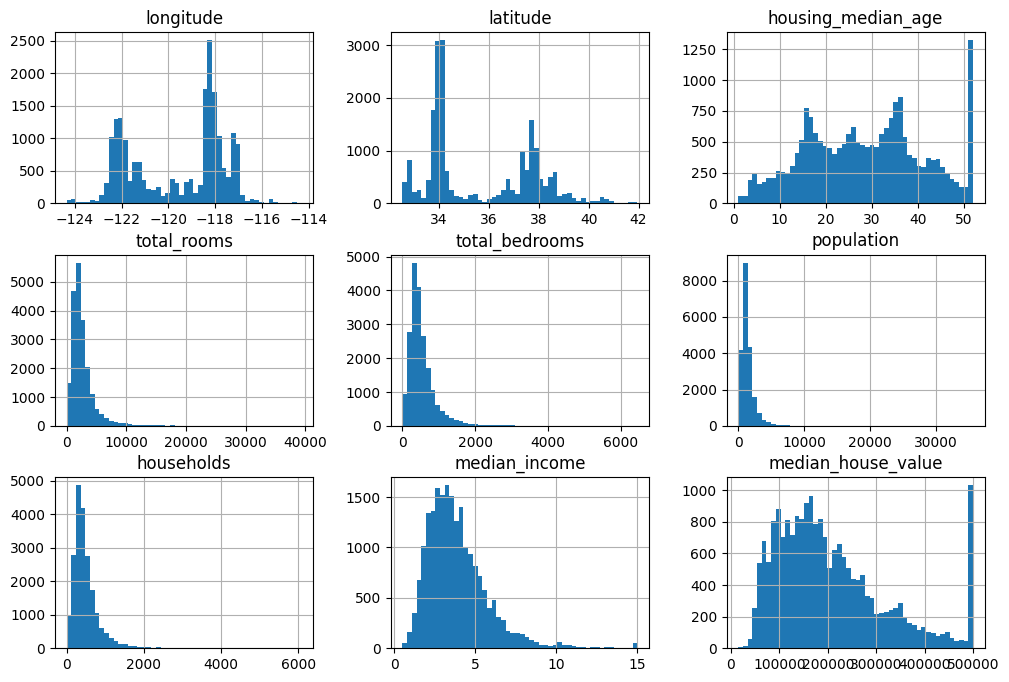

In [22]:
housing_full.hist(bins=50, figsize=(12, 8))
plt.show()

* **First, the median income attribute does not look like it is expressed in US dollars**
**(USD).**

After checking with the team that collected the data, you are told that
the data has been scaled and capped at 15 (actually, 15.0001) for higher median
incomes, and at 0.5 (actually, 0.4999) for lower median incomes

* **The housing median age and the median house value were also capped.**
**The latter may be a serious problem since it is your target attribute (your labels).**

Your
machine learning algorithms may learn that prices never go beyond that limit.

* **Finally, many histograms are skewed right: they extend much farther to the**
**right of the median than to the left.**

This may make it a bit harder for some
machine learning algorithms to detect patterns. 

Later, you’ll try transforming
these attributes to have more symmetrical and bell-shaped distributions

# Create a Test Set


In [23]:
def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]

    return data.iloc[train_indices], data.iloc[test_indices]

To ensure that this notebook's outputs remain the same every time we run it, we need to set the random seed:

In [24]:
rng = np.random.default_rng(seed=42)    # default random number generator
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)

len(train_set)

16512

In [25]:
len(test_set)

4128

This is a stable train/test split method.

Instead of randomly shuffling rows, it decides whether a row belongs in the test set based on its ID.

* **Computes a deterministic hash (a large integer) from the ID.**

* **About test_ratio fraction of IDs will satisfy this condition.**
  **Those rows go into the test set.**

In [26]:
def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

Checks every row's ID and returns True if it belongs in the test set.

Returns:

        Training set: rows with False
        Test set: rows with True

In [27]:
def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))

    return data.loc[~in_test_set], data.loc[in_test_set]

Unfortunately, the housing dataset does not have an identifier column. The simplest
solution is to use the row index as the ID:


In [28]:
housing_with_id = housing_full.reset_index()    # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [29]:
train_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
6,6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


If you use the row index as a unique identifier, you need to make sure that new data
gets appended to the end of the dataset and that no row ever gets deleted. If this is not
possible, then you can try to use the most stable features to build a unique identifier.

For example, a district’s latitude and longitude are guaranteed to be stable for a few
million years, so you could combine them into an ID like so:

In [30]:
housing_with_id["id"] = (housing_full["longitude"] * 1000
                         + housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [31]:
train_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122192.12
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122182.14
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122202.15
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122212.15
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,-121050.52
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,-121170.51
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,-121180.57
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,-121280.57


The location information is actually quite coarse, and as a result many districts will have the exact same ID, so
they will end up in the same set (test or train). This introduces some unfortunate sampling bias.
___

The simplest function is train_test_split(), which does pretty much the
same thing as the shuffle_and_split_data() function we defined earlier, with a
couple of additional features. 

In [32]:
train_set, test_set = train_test_split(housing_full, test_size=0.2, 
                                        random_state=42)

In [33]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

Let’s look at the median income histogram
more closely (back in Figure 2-8): most median income values are clustered around
1.5 to 6 (i.e., $15,000–$60,000), but some median incomes go far beyond 6. 

It is
important to have a sufficient number of instances in your dataset for each stratum,
or else the estimate of a stratum’s importance may be biased. 

___
This means that you
should not have too many strata, and each stratum should be large enough. 

The
following code uses the pd.cut() function to create an income category attribute
with five categories (labeled from 1 to 5); category 1 ranges from 0 to 1.5 (i.e., less
than $15,000), category 2 from 1.5 to 3, and so on:


In [34]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

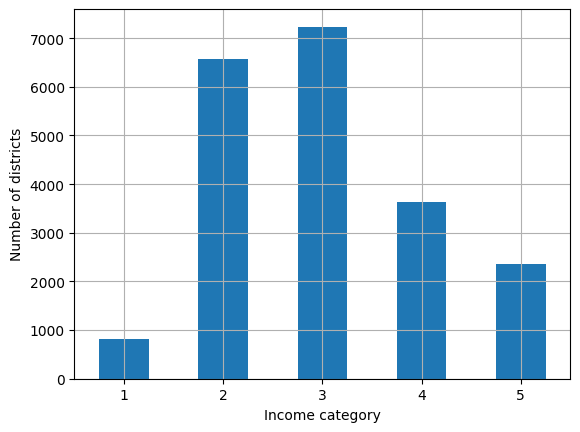

In [35]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

**Split the rows of X, but use the category labels in y to preserve their proportions.**

housing_full (X) = **the data whose rows are going to be split.**

housing_full["income_cat"] (y) = **the labels used to decide how to split.**

---

It uses income_cat to:

* **Find which rows belong to each income category.**

* **Randomly pick 20% of the rows from each category for the test set.**

* **Put the rest in the training set.**

So the indices are generated based on the positions of rows within each income category, while housing_full simply provides the rows those indices refer to.

In [36]:
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full,
                                              housing_full["income_cat"]):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

is equivalent to:

strat_train_set = strat_splits[0][0]

strat_test_set = strat_splits[0][1]

In plain English: 

"Take the first train/test split from the 10 generated splits and store its training set and test set in these two variables."

In [37]:
strat_train_set, strat_test_set = strat_splits[0]

there’s a shorter way to get a single
split using the train_test_split() function with the stratify argument:

* Split housing_full into 80% training and 20% testing.

* stratify=housing_full["income_cat"] ensures the income category proportions are preserved in both sets.

This is a simpler way to do what StratifiedShuffleSplit was doing.

___

* **Count how many rows belong to each income category in the test set.**

* **Divide by the total number of rows in the test set.**

* **Result: the fraction (or percentage) of the test set in each income category.**

Meaning:

* 35% are in category 1,
* 31% in category 2,
etc.

In [38]:
strat_train_set, strat_test_set = train_test_split(housing_full,
                                                   test_size=0.2,
                                                   stratify=housing_full["income_cat"],
                                                   random_state=42)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

This is usually done to verify that stratification worked correctly.

In [39]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_full),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


With similar code you can measure the income category proportions in the full data‐
set. Figure 2-10 compares the income category proportions in the overall dataset, in
the test set generated with stratified sampling, and in a test set generated using purely
random sampling. 

As you can see, the test set generated using stratified sampling has
income category proportions almost identical to those in the full dataset, whereas the
test set generated using purely random sampling is skewed.

___
**With stratification**, scikit-learn effectively says:

stratify=housing_full["income_cat"]

"For each income category, put 20% of its rows into the test set."

**Without stratification:**

scikit-learn says:

"Pick 20% of all rows at random."

It still takes 20% overall, but it doesn't care whether each income category contributes its proportional share. That's where the skew can come from.

You won’t use the income_cat column again, so you might as well drop it, reverting
the data back to its original state:

In [40]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

We spent quite a bit of time on test set generation for a good reason: this is an often
neglected but critical part of a machine learning project. 

Moreover, many of these
ideas will be useful later when we discuss cross-validation. 

Now it’s time to move on
to the next stage: exploring the data

## Explore and Visualize the Data to Gain Insights

Since you’re going to experiment with various transformations of the full training set, you
should make a copy of the original so you can revert to it afterwards:

In [41]:
housing = strat_test_set.copy()

Setting the alpha option to 0.2 makes it much easier to visualize the places
where there is a high density of data points.

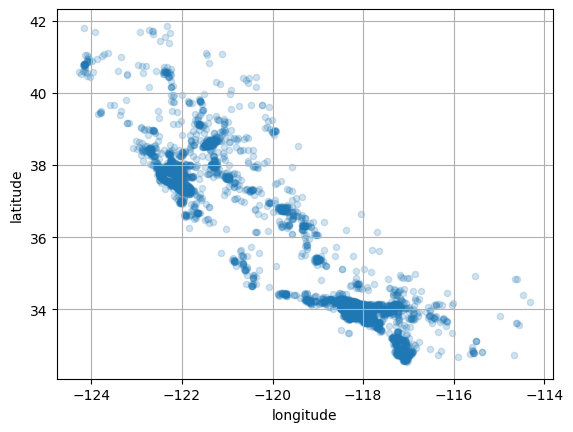

In [42]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid="True", alpha=0.2)
plt.show()

Next, you look at the housing prices (Figure 2-13). 

The radius of each circle represents the district’s population (option s), and the color represents the price (option
c). 

Here you use a predefined color map (option cmap) called jet, which ranges from
blue (low values) to red (high prices)

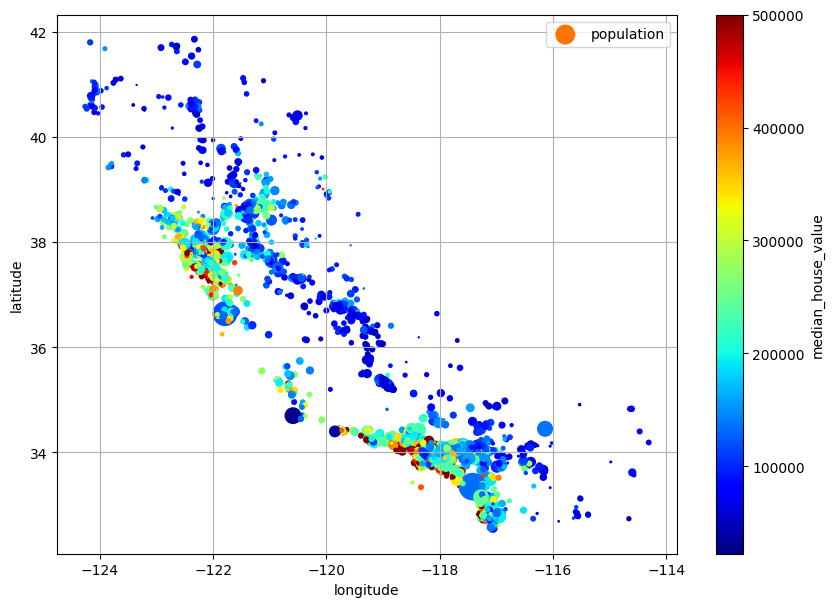

In [43]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
 s=housing["population"] / 100, label="population",
 c="median_house_value", cmap="jet", colorbar=True,
 legend=True, sharex=False, figsize=(10, 7))

plt.show()

This image tells you that the housing prices are very much related to the location
(e.g., close to the ocean) and to the population density, as you probably knew already.

## Look for Correlations


Since the dataset is not too large, you can easily compute the standard correlation
coefficient (also called **Pearson’s r**) between every pair of numerical attributes using the
corr() method:

In [44]:
corr_matrix = housing.corr(numeric_only=True)

In [45]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687091
total_rooms           0.121070
housing_median_age    0.118976
households            0.043549
total_bedrooms        0.029600
longitude            -0.026768
population           -0.040286
latitude             -0.162087
Name: median_house_value, dtype: float64

___
The correlation coefficient ranges from –1 to 1. 

When it is close to 1, it means that
there is a strong positive correlation; for example, the median house value tends to
go up when the median income goes up & viceversa. 

Finally, coefficients close to 0 mean that there is no
linear correlation.


___
Another way to check for correlation between attributes is to use the Pandas
scatter_matrix() function, which plots every numerical attribute against every
other numerical attribute:

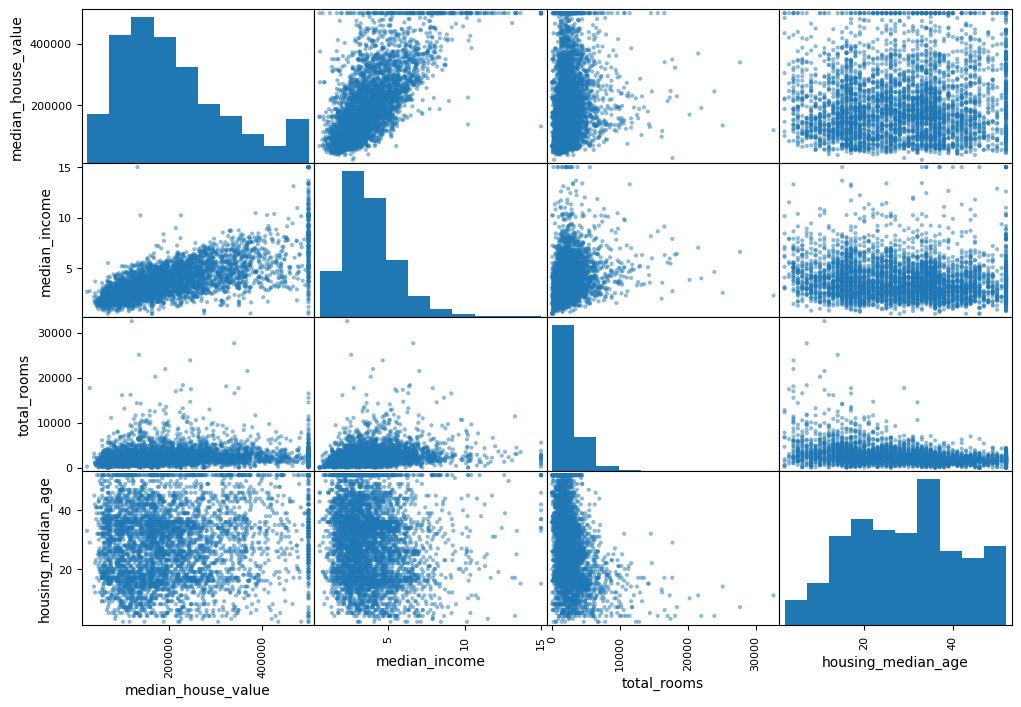

In [46]:
# Focus on a few promising attributes
attributes = ["median_house_value", "median_income", "total_rooms",
 "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

This scatter matrix plots every numerical attribute against every other
numerical attribute, plus a histogram of each numerical attribute’s values on the main
diagonal (top left to bottom right)

___
Note that the correlation coefficient only measures linear correlations (“as x goes up,
y generally goes up/down”). 

It may completely miss out on nonlinear relationships
(e.g., “as x approaches 0, y generally goes up”)

## Experiment with Attribute Combinations

___
One last thing you may want to do before preparing the data for machine learning
algorithms is to try out various attribute combinations. 

* For example, the total num‐
ber of rooms in a district is not very useful if you don’t know how many households
there are. What you really want is the number of rooms per household. 

* Similarly, the
total number of bedrooms by itself is not very useful: you probably want to compare
it to the total number of rooms. And the population per household also seems like
an interesting attribute combination to look at. 

You create these new attributes as
follows:

In [47]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

And then you look at the correlation matrix again:

In [48]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687091
rooms_per_house       0.198322
total_rooms           0.121070
housing_median_age    0.118976
households            0.043549
total_bedrooms        0.029600
people_per_house     -0.025974
longitude            -0.026768
population           -0.040286
latitude             -0.162087
bedrooms_ratio       -0.254506
Name: median_house_value, dtype: float64

___
Hey, not bad! 

The new bedrooms_ratio attribute is much more correlated with the
median house value than the total number of rooms or bedrooms. It’s a strong
negative correlation, so it looks like houses with a lower bedroom/room ratio tend
to be more expensive. 

The number of rooms per household is also more informative
than the total number of rooms in a district—obviously the larger the houses, the
more expensive they are.

___
This is one of the first examples of __feature engineering__: instead of feeding the model raw measurements, you create a feature that captures a more meaningful relationship. 

It's a glimpse into one of the most powerful ideas in machine learning: sometimes the right representation of the data matters more than having more data.

___
When creating new combined features, make sure they are not
too linearly correlated with existing features: 

In particular,
avoid simple weighted sums of existing features.


## Prepare the Data for Machine Learning Algorithms

Let's revert to the original training set and separate the target 

(note that strat_train_set.drop() creates a copy of strat_train_set without the column, it doesn't actually modify strat_train_set itself, unless you pass inplace=True):

In [49]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

Note: The above cell resets the housing dataframe, also removing the custom features we just added. 

We are doing this because, later in the chapter, we will build an automated 'transformation pipeline' to handle all these steps at once.

## Clean the Data

Most machine learning algorithms cannot work with **missing features**, so you’ll need
 to take care of these. 
 
 For example, you noticed earlier that the total_bedrooms
 attribute has some missing values. You have three options to fix this:

 1. Get rid of the corresponding districts.
 
 2. Get rid of the whole attribute.

 3. Set the missing values to some value (zero, the mean, the median, etc.). This is
 called imputation.

___
You can accomplish these easily using the Pandas DataFrame’s dropna(), drop(), and
 fillna() methods:
 
 * housing.dropna(subset=["total_bedrooms"], inplace=True)  # option 1

 * housing.drop("total_bedrooms", axis=1, inplace=True)  # option 2

 * median = housing["total_bedrooms"].median()  # option 3
 
    housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

___
 You decide to go for option 3 since it is the least destructive, but instead of the
 preceding code, you will use a handy Scikit-Learn class: SimpleImputer.

In [51]:
imputer = SimpleImputer(strategy="median")

Since the median can only be computed on numerical attributes, you then need to
 create a copy of the data with only the numerical attributes (this will exclude the text
 attribute ocean_proximity):

In [52]:
housing_num = housing.select_dtypes(include=[np.number])

Now you can fit the imputer instance to the training data using the fit() method:

In [53]:
imputer.fit(housing_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['longitude','latitude','housing_median_age',...,'population','households', 'median_income']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](8,)","[-118.51, 34.26, 29. ,...,1167. , 408. , 3.54]"


The imputer has simply computed the median of each attribute and stored the result
 in its statistics_ instance variable. 
 
 Only the total_bedrooms attribute had missing
 values, but you cannot be sure that there won’t be any missing values in new data
 after the system goes live, so it is safer to apply the imputer to all the numerical
 attributes:

In [54]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [55]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

 Now you can use this “trained” imputer to transform the training set by replacing
 missing values with the learned medians:

In [56]:
X = imputer.transform(housing_num)

Missing values can also be replaced with the mean value (strategy="mean"), or
 with the most frequent value (strategy="most_frequent"), or with a constant
 value (strategy="constant", fill_value=…). 
 
 The last two strategies support non
numerical data.